In [13]:
# Cell 01: Environment Setup and Imports
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Union

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.preprocessing import StandardScaler, MinMaxScaler

warnings.filterwarnings('ignore')
plt.style.use('default')

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Create artifacts directory
artifacts_dir = Path("./artifacts_patchtst")
artifacts_dir.mkdir(exist_ok=True)

print("✓ Environment setup complete")


Using device: cuda
GPU: NVIDIA GeForce RTX 4090
✓ Environment setup complete


In [14]:
# Cell 02: Data Loading and Validation
def load_and_validate_data():
    """Load and validate train/validation datasets"""
    
    # Data paths
    train_path = "./dataset_new/train.csv"
    val_path = "./dataset_new/Validation.csv"
    
    # Validate file existence
    assert os.path.exists(train_path), f"Train file not found: {train_path}"
    assert os.path.exists(val_path), f"Validation file not found: {val_path}"
    
    # Load data
    print("Loading datasets...")
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    
    print(f"Train data shape: {train_df.shape}")
    print(f"Validation data shape: {val_df.shape}")
    
    # Validate required columns
    required_cols = ['date', 'store_menu', 'sales', 'store', 'menu']
    for col in required_cols:
        assert col in train_df.columns, f"Required column '{col}' not found in train data"
        assert col in val_df.columns, f"Required column '{col}' not found in validation data"
    
    # Convert date column
    train_df['date'] = pd.to_datetime(train_df['date'])
    val_df['date'] = pd.to_datetime(val_df['date'])
    
    # Clip negative sales to 0 (prevent data leakage)
    print(f"Negative sales in train: {(train_df['sales'] < 0).sum()}")
    print(f"Negative sales in validation: {(val_df['sales'] < 0).sum()}")
    
    train_df['sales'] = train_df['sales'].clip(lower=0)
    val_df['sales'] = val_df['sales'].clip(lower=0)
    
    # Data range validation
    print(f"Train date range: {train_df['date'].min()} to {train_df['date'].max()}")
    print(f"Validation date range: {val_df['date'].min()} to {val_df['date'].max()}")
    
    # Store-menu combinations
    train_store_menus = set(train_df['store_menu'].unique())
    val_store_menus = set(val_df['store_menu'].unique())
    
    print(f"Train store_menus: {len(train_store_menus)}")
    print(f"Validation store_menus: {len(val_store_menus)}")
    print(f"Common store_menus: {len(train_store_menus.intersection(val_store_menus))}")
    
    return train_df, val_df

# Load data
train_df, val_df = load_and_validate_data()

# Handle missing and infinite values
def handle_missing_infinite_values(df, dataset_name):
    """Handle missing values and infinite values in the dataset"""
    print(f"\n🔧 Processing missing/infinite values for {dataset_name}...")
    
    # Replace infinite values with NaN
    df = df.replace([np.inf, -np.inf], np.nan)
    
    # Check for missing values
    missing_stats = df.isnull().sum()
    missing_cols = missing_stats[missing_stats > 0]
    
    if len(missing_cols) > 0:
        print(f"Columns with missing values:")
        for col, count in missing_cols.items():
            pct = (count / len(df)) * 100
            print(f"  {col}: {count} ({pct:.2f}%)")
    
    # Fill missing values based on column type
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    categorical_cols = df.select_dtypes(include=['object']).columns
    
    # For numeric columns: fill with 0 (safe for time series features)
    for col in numeric_cols:
        if col != 'sales':  # Don't touch sales column
            df[col] = df[col].fillna(0)
    
    # For categorical columns: fill with 'unknown' or mode
    for col in categorical_cols:
        if col not in ['date', 'store_menu', 'store', 'menu']:
            df[col] = df[col].fillna('unknown')
    
    # Final check for any remaining NaN values
    remaining_nan = df.isnull().sum().sum()
    print(f"Remaining NaN values after processing: {remaining_nan}")
    
    return df

# Process both datasets
train_df = handle_missing_infinite_values(train_df, "train")
val_df = handle_missing_infinite_values(val_df, "validation")

# Display basic statistics
print("\nTrain data info:")
print(train_df.info())
print("\nSales statistics:")
print(train_df['sales'].describe())

# Check for any infinite values in key columns
print("\nInfinite value check:")
for col in ['sales'] + [c for c in train_df.columns if 'lag' in c or 'roll' in c or 'mean' in c][:5]:
    if col in train_df.columns:
        inf_count = np.isinf(train_df[col]).sum()
        print(f"{col}: {inf_count} infinite values")

print("✓ Data loading and preprocessing complete")

Loading datasets...
Train data shape: (102676, 128)
Validation data shape: (6755, 128)
Negative sales in train: 0
Negative sales in validation: 0
Train date range: 2023-01-01 00:00:00 to 2024-06-15 00:00:00
Validation date range: 2024-06-09 00:00:00 to 2024-07-13 00:00:00
Train store_menus: 193
Validation store_menus: 193
Common store_menus: 193

🔧 Processing missing/infinite values for train...
Columns with missing values:
  lag_1: 193 (0.19%)
  lag_7: 1351 (1.32%)
  lag_14: 2702 (2.63%)
  lag_28: 5404 (5.26%)
  roll_mean_7: 193 (0.19%)
  roll_mean_14: 193 (0.19%)
  roll_std_7: 386 (0.38%)
  roll_std_14: 386 (0.38%)
  same_dow_mean4: 1351 (1.32%)
  IZI: 7448 (7.25%)
  IZI_store: 59584 (58.03%)
Remaining NaN values after processing: 0

🔧 Processing missing/infinite values for validation...
Columns with missing values:
  lag_1: 193 (2.86%)
  lag_7: 1351 (20.00%)
  lag_14: 2702 (40.00%)
  lag_28: 5404 (80.00%)
  roll_mean_7: 193 (2.86%)
  roll_mean_14: 193 (2.86%)
  roll_std_7: 386 (5.71

In [15]:
# Cell 03: Cross-Validation Setup
def create_cv_folds(train_df, lookback=28, horizon=7, max_folds=15):
    """Create cross-validation folds with sliding window approach"""
    
    # Sort by store_menu and date
    train_df_sorted = train_df.sort_values(['store_menu', 'date'])
    
    # Get date range
    min_date = train_df_sorted['date'].min()
    max_date = train_df_sorted['date'].max()
    total_days = (max_date - min_date).days + 1
    
    print(f"Total training days: {total_days}")
    
    # Calculate possible folds
    fold_size = lookback + horizon  # 35 days per fold
    possible_folds = (total_days - lookback) // horizon  # Maximum possible folds
    
    print(f"Possible folds: {possible_folds}")
    print(f"Max folds requested: {max_folds}")
    
    # Select representative folds for seasonal diversity
    if possible_folds > max_folds:
        # Sample folds to cover different seasons
        fold_indices = np.linspace(0, possible_folds-1, max_folds, dtype=int)
    else:
        fold_indices = list(range(possible_folds))
    
    print(f"Selected fold indices: {fold_indices}")
    
    # Create fold definitions
    folds = []
    for i, fold_idx in enumerate(fold_indices):
        # Calculate dates for this fold - Fix: convert numpy int to regular int
        val_start_offset = lookback + int(fold_idx) * horizon
        val_end_offset = val_start_offset + horizon - 1
        train_end_offset = val_start_offset - 1
        
        train_start_date = min_date
        train_end_date = min_date + timedelta(days=int(train_end_offset))
        val_start_date = min_date + timedelta(days=int(val_start_offset))
        val_end_date = min_date + timedelta(days=int(val_end_offset))
        
        if val_end_date <= max_date:  # Ensure we don't exceed data range
            folds.append({
                'fold_id': i,
                'train_start': train_start_date,
                'train_end': train_end_date,
                'val_start': val_start_date,
                'val_end': val_end_date
            })
    
    print(f"Created {len(folds)} folds")
    for fold in folds[:3]:  # Show first 3 folds
        print(f"Fold {fold['fold_id']}: Train({fold['train_start']:%Y-%m-%d} to {fold['train_end']:%Y-%m-%d}), "
              f"Val({fold['val_start']:%Y-%m-%d} to {fold['val_end']:%Y-%m-%d})")
    
    return folds

# Create CV folds
cv_folds = create_cv_folds(train_df)

print("✓ Cross-validation setup complete")


Total training days: 532
Possible folds: 72
Max folds requested: 15
Selected fold indices: [ 0  5 10 15 20 25 30 35 40 45 50 55 60 65 71]
Created 15 folds
Fold 0: Train(2023-01-01 to 2023-01-28), Val(2023-01-29 to 2023-02-04)
Fold 1: Train(2023-01-01 to 2023-03-04), Val(2023-03-05 to 2023-03-11)
Fold 2: Train(2023-01-01 to 2023-04-08), Val(2023-04-09 to 2023-04-15)
✓ Cross-validation setup complete


In [16]:
# Cell 04: PatchTST Model Implementation
class PatchTST(nn.Module):
    """
    PatchTST model for time series forecasting
    Based on channel-independent patching approach
    """
    def __init__(self, 
                 n_channels: int,
                 patch_len: int = 16,
                 stride: int = 8,
                 d_model: int = 128,
                 n_heads: int = 8,
                 n_layers: int = 3,
                 d_ff: int = 256,
                 dropout: float = 0.1,
                 lookback: int = 28,
                 horizon: int = 7,
                 norm_type: str = 'batch'):
        super().__init__()
        
        self.n_channels = n_channels
        self.patch_len = patch_len
        self.stride = stride
        self.d_model = d_model
        self.lookback = lookback
        self.horizon = horizon
        
        # Calculate number of patches
        self.n_patches = (lookback - patch_len) // stride + 1
        
        # Patch embedding
        self.patch_embedding = nn.Linear(patch_len, d_model)
        
        # Positional encoding
        self.pos_encoding = nn.Parameter(torch.randn(self.n_patches, d_model))
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # Output projection (per channel)
        self.output_projection = nn.ModuleList([
            nn.Sequential(
                nn.Flatten(start_dim=-2),
                nn.Linear(self.n_patches * d_model, horizon),
                nn.Dropout(dropout)
            ) for _ in range(n_channels)
        ])
        
        # Instance normalization (per channel)
        self.instance_norm = nn.ModuleList([
            nn.LayerNorm(lookback) for _ in range(n_channels)
        ])
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        """Initialize weights"""
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
    
    def create_patches(self, x):
        """Create patches from time series
        Args:
            x: (batch_size, n_channels, seq_len)
        Returns:
            patches: (batch_size, n_channels, n_patches, patch_len)
        """
        batch_size, n_channels, seq_len = x.shape
        
        # Create patches using unfold
        patches = x.unfold(dimension=-1, size=self.patch_len, step=self.stride)
        # patches: (batch_size, n_channels, n_patches, patch_len)
        
        return patches
    
    def forward(self, x):
        """
        Forward pass
        Args:
            x: (batch_size, n_channels, seq_len)
        Returns:
            output: (batch_size, horizon) - only sales predictions
        """
        batch_size, n_channels, seq_len = x.shape
        
        # Validate input shape
        assert seq_len == self.lookback, f"Expected seq_len={self.lookback}, got {seq_len}"
        assert n_channels == self.n_channels, f"Expected n_channels={self.n_channels}, got {n_channels}"
        
        # Instance normalization per channel
        x_norm = torch.stack([
            self.instance_norm[i](x[:, i, :]) for i in range(n_channels)
        ], dim=1)
        
        # Create patches
        patches = self.create_patches(x_norm)  # (B, C, n_patches, patch_len)
        
        # Process each channel independently
        channel_outputs = []
        
        for c in range(n_channels):
            # Get patches for this channel
            channel_patches = patches[:, c, :, :]  # (B, n_patches, patch_len)
            
            # Patch embedding
            embedded_patches = self.patch_embedding(channel_patches)  # (B, n_patches, d_model)
            
            # Add positional encoding
            embedded_patches = embedded_patches + self.pos_encoding.unsqueeze(0)
            
            # Transformer encoding
            encoded = self.transformer(embedded_patches)  # (B, n_patches, d_model)
            
            # Output projection for this channel
            output = self.output_projection[c](encoded)  # (B, horizon)
            channel_outputs.append(output)
        
        # For this task, we only predict sales (first channel)
        # Return only sales predictions
        sales_predictions = channel_outputs[0]  # (B, horizon)
        
        return sales_predictions

# Model configuration
MODEL_CONFIG = {
    'patch_len': 7,
    'stride': 1,
    'd_model': 128,
    'n_heads': 8,
    'n_layers': 3,
    'd_ff': 256,
    'dropout': 0.1,
    'lookback': 28,
    'horizon': 7,
    'norm_type': 'batch'
}

print("✓ PatchTST model implemented")
print(f"Model configuration: {MODEL_CONFIG}")

✓ PatchTST model implemented
Model configuration: {'patch_len': 7, 'stride': 1, 'd_model': 128, 'n_heads': 8, 'n_layers': 3, 'd_ff': 256, 'dropout': 0.1, 'lookback': 28, 'horizon': 7, 'norm_type': 'batch'}


In [17]:
# Cell 05: Dataset and DataLoader Implementation
class TimeSeriesDataset(Dataset):
    """Dataset for time series forecasting with sliding windows"""
    
    def __init__(self, df, feature_cols, target_col='sales', lookback=28, horizon=7, 
                 is_train=True, scaler=None):
        """
        Args:
            df: DataFrame with time series data
            feature_cols: List of feature column names
            target_col: Target column name
            lookback: Number of historical days to use
            horizon: Number of days to predict
            is_train: Whether this is training data (for normalization)
            scaler: Pre-fitted scaler for features
        """
        self.lookback = lookback
        self.horizon = horizon
        self.feature_cols = feature_cols
        self.target_col = target_col
        
        # Sort data by store_menu and date
        self.df = df.sort_values(['store_menu', 'date']).reset_index(drop=True)
        
        # Create sliding windows
        self.samples = self._create_sliding_windows()
        
        # Setup scalers
        if is_train:
            self.scaler = StandardScaler()
            # Fit scaler only on training data
            all_features = []
            for sample in self.samples:
                features = sample['features']  # (n_features, lookback)
                all_features.append(features.T)  # (lookback, n_features)
            
            if all_features:
                all_features = np.concatenate(all_features, axis=0)
                self.scaler.fit(all_features)
        else:
            self.scaler = scaler
        
        print(f"Created {len(self.samples)} samples")
    
    def _create_sliding_windows(self):
        """Create sliding window samples for all store_menu combinations"""
        samples = []
        
        for store_menu in self.df['store_menu'].unique():
            store_data = self.df[self.df['store_menu'] == store_menu].copy()
            store_data = store_data.sort_values('date').reset_index(drop=True)
            
            # Create sliding windows for this store_menu
            for i in range(len(store_data) - self.lookback - self.horizon + 1):
                # Historical window
                hist_data = store_data.iloc[i:i+self.lookback]
                # Future window
                future_data = store_data.iloc[i+self.lookback:i+self.lookback+self.horizon]
                
                # Extract features and targets
                features = hist_data[self.feature_cols].values.T  # (n_features, lookback)
                targets = future_data[self.target_col].values  # (horizon,)
                
                # Validate shapes
                assert features.shape == (len(self.feature_cols), self.lookback), \
                    f"Features shape mismatch: {features.shape} vs {(len(self.feature_cols), self.lookback)}"
                assert targets.shape == (self.horizon,), \
                    f"Targets shape mismatch: {targets.shape} vs {(self.horizon,)}"
                
                samples.append({
                    'store_menu': store_menu,
                    'features': features,
                    'targets': targets,
                    'start_date': hist_data.iloc[0]['date'],
                    'end_date': future_data.iloc[-1]['date']
                })
        
        return samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Get features and normalize
        features = sample['features'].astype(np.float32)  # (n_features, lookback)
        targets = sample['targets'].astype(np.float32)   # (horizon,)
        
        # Apply normalization if scaler exists
        if self.scaler is not None:
            features_normalized = self.scaler.transform(features.T).T  # Normalize per timestep
        else:
            features_normalized = features
        
        # Clip targets to prevent negative values
        targets = np.maximum(targets, 0.0)
        
        return {
            'features': torch.from_numpy(features_normalized),  # (n_features, lookback)
            'targets': torch.from_numpy(targets),               # (horizon,)
            'store_menu': sample['store_menu']
        }

# Cell 05: Dataset and DataLoader Implementation

def create_data_loaders(train_df, val_df, feature_cols, fold=None, batch_size=64):
    """Create data loaders for training and validation"""
    LB = MODEL_CONFIG.get('lookback', 28)  # <- 추가

    if fold is not None:
        # train: 그대로
        train_fold_df = train_df[
            (train_df['date'] >= fold['train_start']) &
            (train_df['date'] <= fold['train_end'])
        ].copy()

        # val: 컨텍스트(lookback일) 포함하여 확장  <- 핵심 수정
        ctx_start = fold['val_start'] - pd.Timedelta(days=LB)
        val_fold_df = train_df[
            (train_df['date'] >= ctx_start) &
            (train_df['date'] <= fold['val_end'])
        ].copy()
    else:
        # 외부 val_df를 쓰는 경우도 동일 로직 적용  <- 보강
        train_fold_df = train_df.copy()
        if val_df is not None and len(val_df):
            v_start, v_end = val_df['date'].min(), val_df['date'].max()
            ctx_start = v_start - pd.Timedelta(days=LB)
            val_fold_df = train_df[
                (train_df['date'] >= ctx_start) &
                (train_df['date'] <= v_end)
            ].copy()
        else:
            val_fold_df = train_df.iloc[0:0].copy()

    print(f"Train fold data: {len(train_fold_df)} rows")
    print(f"Val fold data: {len(val_fold_df)} rows")

    # Dataset 생성 (기존과 동일)
    train_dataset = TimeSeriesDataset(
        train_fold_df, feature_cols,
        target_col='sales',
        lookback=MODEL_CONFIG['lookback'], horizon=MODEL_CONFIG['horizon'],
        is_train=True, scaler=None
    )
    val_dataset = TimeSeriesDataset(
        val_fold_df, feature_cols,
        target_col='sales',
        lookback=MODEL_CONFIG['lookback'], horizon=MODEL_CONFIG['horizon'],
        is_train=False, scaler=train_dataset.scaler
    )

    # 빈 데이터셋은 명시적으로 스킵  <- 보강
    if len(train_dataset) == 0 or len(val_dataset) == 0:
        raise ValueError(f"Empty dataset for this fold. train={len(train_dataset)}, val={len(val_dataset)}")

    # DataLoader (기존과 동일)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=4, pin_memory=True, drop_last=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                            num_workers=4, pin_memory=True, drop_last=False)
    return train_loader, val_loader, train_dataset.scaler


# Feature columns for different experiments
SALES_ONLY_COLS = ['sales']
ALL_FEATURE_COLS = [col for col in train_df.columns if col not in ['date', 'store_menu', 'store', 'menu']]

print(f"Sales only features: {len(SALES_ONLY_COLS)}")
print(f"All features: {len(ALL_FEATURE_COLS)}")
print(f"Sample features: {ALL_FEATURE_COLS[:10]}...")

print("✓ Dataset implementation complete")

Sales only features: 1
All features: 124
Sample features: ['sales', 'is_open_obs', 'dow', 'month', 'day', 'is_fri', 'is_sat', 'is_sun', 'is_weekend', 'sin_dow']...
✓ Dataset implementation complete


In [18]:
# Cell 06: Metrics and Loss Functions
def smape(y_true, y_pred, epsilon=1e-8):
    """
    Symmetric Mean Absolute Percentage Error (sMAPE)
    Safe implementation with epsilon to handle zero denominators
    """
    y_true = np.maximum(y_true, 0)  # Ensure non-negative
    y_pred = np.maximum(y_pred, 0)  # Ensure non-negative
    
    numerator = np.abs(y_pred - y_true)
    denominator = np.maximum((np.abs(y_true) + np.abs(y_pred)) / 2, epsilon)
    
    return np.mean(100.0 * numerator / denominator)

def smape_np(y_true, y_pred, eps: float = 1e-8):
    """sMAPE (0~2) with ignoring zero-actual days."""
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    y_pred = np.clip(y_pred, 0, None)  # 음수 예측 금지 규칙을 쓰는 경우
    mask = (np.abs(y_true) > 0)
    if not np.any(mask):
        return np.nan
    num = 2.0 * np.abs(y_true - y_pred)
    den = np.abs(y_true) + np.abs(y_pred) + eps
    return np.mean((num / den)[mask])

def smape_by_series_mean(df, y='sales', yhat='pred', group=('store','menu')):
    vals = []
    for _, g in df.groupby(list(group)):
        m = g[y].abs() > 0
        if m.any():
            vals.append(smape_np(g.loc[m, y].values, g.loc[m, yhat].values))
    return float(np.nanmean(vals)) if len(vals) else np.nan

def smape_ignore_zero(y_true, y_pred, eps: float = 1e-8) -> float:
    yt = np.asarray(y_true, float).reshape(-1)
    yp = np.asarray(y_pred, float).reshape(-1)
    mask = np.isfinite(yt) & np.isfinite(yp) & (np.abs(yt) > 0)
    if not mask.any():
        return 0.0
    num = 2.0 * np.abs(yt - yp)
    den = np.abs(yt) + np.abs(yp) + eps
    return float(np.mean((num / den)[mask]))



def rmse(y_true, y_pred):
    """Root Mean Square Error"""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    """Mean Absolute Error"""
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    """Mean Square Error"""
    return np.mean((y_true - y_pred) ** 2)

# Loss function mapping
LOSS_FUNCTIONS = {
    'rmse': lambda y_pred, y_true: torch.sqrt(F.mse_loss(y_pred, y_true)),
    'mae': F.l1_loss,
    'mse': F.mse_loss
}

def get_loss_function(loss_name):
    """Get loss function by name"""
    if loss_name not in LOSS_FUNCTIONS:
        raise ValueError(f"Unknown loss function: {loss_name}")
    return LOSS_FUNCTIONS[loss_name]

# Evaluation function
def evaluate_model(model, loader, device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in loader:
            x = batch['features'].to(device)
            y = batch['targets'].to(device)
            out = model(x)
            preds.append(out.detach().cpu().float())
            trues.append(y.detach().cpu().float())

    y_pred = torch.cat(preds, 0).numpy()
    y_true = torch.cat(trues, 0).numpy()

    # target scaler로 역변환(없으면 그대로)
    scaler = getattr(loader.dataset, "scaler", None)
    if scaler is not None and hasattr(scaler, "inverse_transform"):
        y_pred = scaler.inverse_transform(y_pred)
        y_true = scaler.inverse_transform(y_true)

    # 규칙 적용
    y_pred = np.clip(y_pred, 0, None)  # 음수 예측 금지 사용 시
    y_pred = np.nan_to_num(y_pred, nan=0.0, posinf=1e9, neginf=0.0)
    y_true = np.nan_to_num(y_true, nan=0.0, posinf=0.0, neginf=0.0)
    return y_pred, y_true


def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    return {
        'smape': smape_ignore_zero(y_true, y_pred),
        'mae': np.mean(np.abs(y_true - y_pred)),
        'mse': np.mean((y_true - y_pred)**2),
        'rmse': float(np.sqrt(np.mean((y_true - y_pred)**2)))
    }



print("✓ Metrics and loss functions implemented")

✓ Metrics and loss functions implemented


In [19]:
# Cell 07: Training Loop Implementation
def train_model(model, train_loader, val_loader, loss_fn, config, fold_id=None):
    """Train model with early stopping based on sMAPE"""
    
    # Training configuration
    epochs = config.get('epochs', 100)
    lr = config.get('lr', 1e-3)
    patience = config.get('patience', 15)
    
    # Setup optimizer and scheduler
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = OneCycleLR(
        optimizer, max_lr=lr, 
        steps_per_epoch=len(train_loader), 
        epochs=epochs, pct_start=0.3
    )
    
    # Enable mixed precision
    scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None
    
    # Training history
    history = {
        'train_loss': [],
        'val_smape': [],
        'learning_rates': []
    }
    
    # Early stopping
    best_val_smape = float('inf')
    patience_counter = 0
    best_model_state = None
    
    print(f"Training for {epochs} epochs...")
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_losses = []
        
        for batch_idx, batch in enumerate(train_loader):
            features = batch['features'].to(device)  # (B, C, L)
            targets = batch['targets'].to(device)    # (B, H)
            
            optimizer.zero_grad()
            
            # Forward pass with mixed precision
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    predictions = model(features)
                    loss = loss_fn(predictions, targets)
                
                # Backward pass
                scaler.scale(loss).backward()
                
                # Gradient clipping
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
                scaler.step(optimizer)
                scaler.update()
            else:
                predictions = model(features)
                loss = loss_fn(predictions, targets)
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            
            scheduler.step()
            train_losses.append(loss.item())
            
            # NaN guard
            if torch.isnan(loss):
                print(f"NaN loss detected at epoch {epoch}, batch {batch_idx}")
                return None, history
        
        # Validation phase
        val_preds, val_targets = evaluate_model(model, val_loader, device)
        # 디버그 로그(원인 추적)
        valid = np.isfinite(val_preds) & np.isfinite(val_targets) & (np.abs(val_targets) > 0)
        print(f"[val] valid_nonzero={valid.sum()}/{val_targets.size}")
        val_smape = smape_ignore_zero(val_targets.reshape(-1), val_preds.reshape(-1))  # ← A=0 제외

        
        # Update history
        avg_train_loss = np.mean(train_losses)
        history['train_loss'].append(avg_train_loss)
        history['val_smape'].append(val_smape)
        history['learning_rates'].append(scheduler.get_last_lr()[0])
        
        # Early stopping check
        if val_smape < best_val_smape:
            best_val_smape = val_smape
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        # Print progress
        if epoch % 10 == 0 or patience_counter == 0:
            print(f"Epoch {epoch:3d} | Train Loss: {avg_train_loss:.4f} | "
                  f"Val sMAPE: {val_smape:.2f} | LR: {scheduler.get_last_lr()[0]:.6f}")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch} (patience: {patience})")
            break
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    print(f"Training completed. Best validation sMAPE: {best_val_smape:.4f}")
    
    return model, history

def run_cross_validation(stage, loss_name, feature_cols, cv_folds, config):
    """Run cross-validation experiment"""
    
    print(f"\n=== Running {stage} - {loss_name} - {len(feature_cols)} features ===")
    
    # Results storage
    fold_results = []
    training_logs = []
    
    # Get loss function
    loss_fn = get_loss_function(loss_name)
    
    # Sample only first 4 folds for computational efficiency
    selected_folds = cv_folds[1:5]
    
    for fold in selected_folds:
        print(f"\n--- Fold {fold['fold_id']} ---")
        print(f"Train: {fold['train_start']:%Y-%m-%d} to {fold['train_end']:%Y-%m-%d}")
        print(f"Val: {fold['val_start']:%Y-%m-%d} to {fold['val_end']:%Y-%m-%d}")
        
        try:
            # Create data loaders
            train_loader, val_loader, scaler = create_data_loaders(
                train_df, val_df, feature_cols, fold=fold, batch_size=config['batch_size']
            )
            
            # Create model
            model = PatchTST(
                n_channels=len(feature_cols),
                **MODEL_CONFIG
            ).to(device)
            
            # Train model
            trained_model, history = train_model(
                model, train_loader, val_loader, loss_fn, config, fold['fold_id']
            )
            
            if trained_model is None:
                print(f"Training failed for fold {fold['fold_id']}")
                continue
            
            # Evaluate on validation set
            val_preds, val_targets = evaluate_model(trained_model, val_loader, device)
            metrics = calculate_metrics(val_targets.flatten(), val_preds.flatten())

            
            fold_result = {
                'fold_id': fold['fold_id'],
                'val_smape': metrics['smape'],
                'val_rmse': metrics['rmse'],
                'val_mae': metrics['mae'],
                'val_mse': metrics['mse'],
                'best_epoch': len(history['train_loss']) - 1
            }
            
            fold_results.append(fold_result)
            
            # Log training progress
            for epoch, (train_loss, val_smape_epoch, lr) in enumerate(zip(
                history['train_loss'], history['val_smape'], history['learning_rates']
            )):
                training_logs.append({
                    'stage': stage,
                    'loss': loss_name,
                    'inputs': 'sales_only' if len(feature_cols) == 1 else 'all_features',
                    'fold_id': fold['fold_id'],
                    'epoch': epoch,
                    'train_loss': train_loss,
                    'val_smape': val_smape_epoch,
                    'learning_rate': lr
                })
            
            print(f"Fold {fold['fold_id']} completed - sMAPE: {metrics['smape']:.4f}")
            
        except Exception as e:
            print(f"Error in fold {fold['fold_id']}: {str(e)}")
            continue
    
    return fold_results, training_logs

# Training configuration
TRAIN_CONFIG = {
    'epochs': 50,
    'lr': 1e-3,
    'patience': 10,
    'batch_size': 128
}

print("✓ Training loop implemented")
print(f"Training config: {TRAIN_CONFIG}")

✓ Training loop implemented
Training config: {'epochs': 50, 'lr': 0.001, 'patience': 10, 'batch_size': 128}


In [8]:
# Cell 08: Stage A Experiments (Input Channel Effects)
print("🚀 Starting Stage A: Input Channel Effects Comparison")
print("=" * 60)

# Initialize experiment tracking
all_results = []
all_training_logs = []

# Stage A1: RMSE + Sales Only
print("\n🔬 Stage A1: RMSE + Sales Only")
start_time = datetime.now()

stage_a1_results, stage_a1_logs = run_cross_validation(
    stage='A1', 
    loss_name='rmse', 
    feature_cols=SALES_ONLY_COLS,
    cv_folds=cv_folds,
    config=TRAIN_CONFIG
)

a1_duration = (datetime.now() - start_time).total_seconds() / 60

# Calculate CV statistics
if stage_a1_results:
    cv_smape_scores = [r['val_smape'] for r in stage_a1_results]
    a1_cv_mean = np.mean(cv_smape_scores)
    a1_cv_std = np.std(cv_smape_scores)
    
    print(f"A1 Results - CV sMAPE: {a1_cv_mean:.4f} ± {a1_cv_std:.4f}")
    
    all_results.append({
        'stage': 'A1',
        'loss': 'rmse',
        'inputs': 'sales_only',
        'n_features': len(SALES_ONLY_COLS),
        'cv_mean_smape': a1_cv_mean,
        'cv_std_smape': a1_cv_std,
        'train_time_min': a1_duration,
        'fold_results': stage_a1_results
    })
    
    all_training_logs.extend(stage_a1_logs)

# Stage A2: RMSE + All Features
print("\n🔬 Stage A2: RMSE + All Features")
start_time = datetime.now()

stage_a2_results, stage_a2_logs = run_cross_validation(
    stage='A2', 
    loss_name='rmse', 
    feature_cols=ALL_FEATURE_COLS,
    cv_folds=cv_folds,
    config=TRAIN_CONFIG
)

a2_duration = (datetime.now() - start_time).total_seconds() / 60

# Calculate CV statistics
if stage_a2_results:
    cv_smape_scores = [r['val_smape'] for r in stage_a2_results]
    a2_cv_mean = np.mean(cv_smape_scores)
    a2_cv_std = np.std(cv_smape_scores)
    
    print(f"A2 Results - CV sMAPE: {a2_cv_mean:.4f} ± {a2_cv_std:.4f}")
    
    all_results.append({
        'stage': 'A2',
        'loss': 'rmse',
        'inputs': 'all_features',
        'n_features': len(ALL_FEATURE_COLS),
        'cv_mean_smape': a2_cv_mean,
        'cv_std_smape': a2_cv_std,
        'train_time_min': a2_duration,
        'fold_results': stage_a2_results
    })
    
    all_training_logs.extend(stage_a2_logs)

# Stage A Summary
print("\n📊 Stage A Summary")
print("=" * 40)

stage_a_df = pd.DataFrame([r for r in all_results if r['stage'].startswith('A')])
if len(stage_a_df) > 0:
    stage_a_df['inputs_display'] = stage_a_df['inputs'].map({
        'sales_only': 'Sales Only',
        'all_features': 'All Features'
    })
    
    print(stage_a_df[['stage', 'inputs_display', 'n_features', 'cv_mean_smape', 'cv_std_smape', 'train_time_min']])

print("✓ Stage A experiment setup complete")

🚀 Starting Stage A: Input Channel Effects Comparison

🔬 Stage A1: RMSE + Sales Only

=== Running A1 - rmse - 1 features ===

--- Fold 1 ---
Train: 2023-01-01 to 2023-03-04
Val: 2023-03-05 to 2023-03-11
Train fold data: 12159 rows
Val fold data: 6755 rows
Created 5597 samples
Created 193 samples
Training for 50 epochs...
Epoch   0 | Train Loss: 56.1660 | Val sMAPE: 1.21 | LR: 0.000051
Epoch   6 | Train Loss: 44.8110 | Val sMAPE: 1.16 | LR: 0.000471
Epoch  10 | Train Loss: 40.4961 | Val sMAPE: 1.29 | LR: 0.000842
Epoch  12 | Train Loss: 37.8238 | Val sMAPE: 1.13 | LR: 0.000959
Epoch  18 | Train Loss: 35.2844 | Val sMAPE: 1.12 | LR: 0.000968
Epoch  19 | Train Loss: 34.3483 | Val sMAPE: 0.97 | LR: 0.000950
Epoch  20 | Train Loss: 33.3052 | Val sMAPE: 1.19 | LR: 0.000929
Epoch  22 | Train Loss: 33.0878 | Val sMAPE: 0.93 | LR: 0.000876
Epoch  30 | Train Loss: 28.3370 | Val sMAPE: 1.12 | LR: 0.000566
Early stopping at epoch 32 (patience: 10)
Training completed. Best validation sMAPE: 0.9341
F

In [9]:
# Cell 09: Stage B Experiments (Loss Function Comparison)
print("\n🚀 Starting Stage B: Loss Function Effects (All Features)")
print("=" * 60)

# Use all features for Stage B (fixed from Stage A results)
stage_b_features = ALL_FEATURE_COLS

# Stage B1: MAE + All Features
print("\n🔬 Stage B1: MAE + All Features")
start_time = datetime.now()

stage_b1_results, stage_b1_logs = run_cross_validation(
    stage='B1', 
    loss_name='mae', 
    feature_cols=stage_b_features,
    cv_folds=cv_folds,
    config=TRAIN_CONFIG
)

b1_duration = (datetime.now() - start_time).total_seconds() / 60

# Calculate CV statistics
if stage_b1_results:
    cv_smape_scores = [r['val_smape'] for r in stage_b1_results]
    b1_cv_mean = np.mean(cv_smape_scores)
    b1_cv_std = np.std(cv_smape_scores)
    
    print(f"B1 Results - CV sMAPE: {b1_cv_mean:.4f} ± {b1_cv_std:.4f}")
    
    all_results.append({
        'stage': 'B1',
        'loss': 'mae',
        'inputs': 'all_features',
        'n_features': len(stage_b_features),
        'cv_mean_smape': b1_cv_mean,
        'cv_std_smape': b1_cv_std,
        'train_time_min': b1_duration,
        'fold_results': stage_b1_results
    })
    
    all_training_logs.extend(stage_b1_logs)

# Stage B2: MSE + All Features
print("\n🔬 Stage B2: MSE + All Features")
start_time = datetime.now()

stage_b2_results, stage_b2_logs = run_cross_validation(
    stage='B2', 
    loss_name='mse', 
    feature_cols=stage_b_features,
    cv_folds=cv_folds,
    config=TRAIN_CONFIG
)

b2_duration = (datetime.now() - start_time).total_seconds() / 60

# Calculate CV statistics
if stage_b2_results:
    cv_smape_scores = [r['val_smape'] for r in stage_b2_results]
    b2_cv_mean = np.mean(cv_smape_scores)
    b2_cv_std = np.std(cv_smape_scores)
    
    print(f"B2 Results - CV sMAPE: {b2_cv_mean:.4f} ± {b2_cv_std:.4f}")
    
    all_results.append({
        'stage': 'B2',
        'loss': 'mse',
        'inputs': 'all_features',
        'n_features': len(stage_b_features),
        'cv_mean_smape': b2_cv_mean,
        'cv_std_smape': b2_cv_std,
        'train_time_min': b2_duration,
        'fold_results': stage_b2_results
    })
    
    all_training_logs.extend(stage_b2_logs)

# Stage B3: RMSE + All Features (repeat from A2 for comparison)
print("\n🔬 Stage B3: RMSE + All Features")
# Use A2 results for B3 (same configuration)
if any(r['stage'] == 'A2' for r in all_results):
    a2_result = [r for r in all_results if r['stage'] == 'A2'][0]
    b3_result = a2_result.copy()
    b3_result['stage'] = 'B3'
    all_results.append(b3_result)
    print(f"B3 Results - CV sMAPE: {b3_result['cv_mean_smape']:.4f} ± {b3_result['cv_std_smape']:.4f}")

# Stage B Summary
print("\n📊 Stage B Summary")
print("=" * 40)

stage_b_df = pd.DataFrame([r for r in all_results if r['stage'].startswith('B')])
if len(stage_b_df) > 0:
    stage_b_df['loss_display'] = stage_b_df['loss'].str.upper()
    print(stage_b_df[['stage', 'loss_display', 'cv_mean_smape', 'cv_std_smape', 'train_time_min']])

print("✓ Stage B experiment setup complete")



🚀 Starting Stage B: Loss Function Effects (All Features)

🔬 Stage B1: MAE + All Features

=== Running B1 - mae - 124 features ===

--- Fold 1 ---
Train: 2023-01-01 to 2023-03-04
Val: 2023-03-05 to 2023-03-11
Train fold data: 12159 rows
Val fold data: 6755 rows
Created 5597 samples
Created 193 samples
Training for 50 epochs...
Epoch   0 | Train Loss: 17.8718 | Val sMAPE: 1.05 | LR: 0.000051
Epoch   1 | Train Loss: 17.7016 | Val sMAPE: 1.03 | LR: 0.000082
Epoch   2 | Train Loss: 17.5364 | Val sMAPE: 0.87 | LR: 0.000132
Epoch   3 | Train Loss: 17.3215 | Val sMAPE: 0.73 | LR: 0.000199
Epoch   4 | Train Loss: 17.0697 | Val sMAPE: 0.71 | LR: 0.000281
Epoch  10 | Train Loss: 13.2714 | Val sMAPE: 0.85 | LR: 0.000842
Early stopping at epoch 14 (patience: 10)
Training completed. Best validation sMAPE: 0.7105
Fold 1 completed - sMAPE: 1.0114

--- Fold 2 ---
Train: 2023-01-01 to 2023-04-08
Val: 2023-04-09 to 2023-04-15
Train fold data: 18914 rows
Val fold data: 6755 rows
Created 12352 samples
Cre

In [20]:
# Cell 10: Final Validation Evaluation
def evaluate_on_validation_set(best_config):
    """Train best model on full training data and evaluate on validation set"""
    
    print(f"\n🎯 Final Validation Evaluation")
    print("=" * 50)
    
    # Get best configuration
    stage = best_config['stage']
    loss_name = best_config['loss']
    feature_cols = ALL_FEATURE_COLS if best_config['inputs'] == 'all_features' else SALES_ONLY_COLS
    
    print(f"Best config: {stage} - {loss_name.upper()} - {len(feature_cols)} features")
    
    # Create data loaders (full training data vs validation data)
    train_loader, val_loader, scaler = create_data_loaders(
        train_df, val_df, feature_cols, fold=None, batch_size=TRAIN_CONFIG['batch_size']
    )
    
    # Create and train final model
    final_model = PatchTST(
        n_channels=len(feature_cols),
        **MODEL_CONFIG
    ).to(device)
    
    loss_fn = get_loss_function(loss_name)
    
    # Train on full training data
    print("Training final model on full training data...")
    trained_model, history = train_model(
        final_model, train_loader, val_loader, loss_fn, TRAIN_CONFIG, fold_id='final'
    )
    
    if trained_model is None:
        print("Final training failed!")
        return None
    
    # Evaluate on validation set
    val_preds, val_targets = evaluate_model(trained_model, val_loader, device)
    final_metrics = calculate_metrics(val_targets.flatten(), val_preds.flatten())
    
    print(f"\n🏆 Final Validation Results:")
    print(f"sMAPE: {final_metrics['smape']:.4f}")
    print(f"RMSE:  {final_metrics['rmse']:.4f}")
    print(f"MAE:   {final_metrics['mae']:.4f}")
    print(f"MSE:   {final_metrics['mse']:.4f}")
    
    # Save final model
    model_path = artifacts_dir / f"{stage}_{loss_name}_{best_config['inputs']}_best.ckpt"
    torch.save({
        'model_state_dict': trained_model.state_dict(),
        'config': best_config,
        'model_config': MODEL_CONFIG,
        'feature_cols': feature_cols,
        'scaler': scaler,
        'final_metrics': final_metrics
    }, model_path)
    
    print(f"Final model saved to {model_path}")
    
    return {
        'model': trained_model,
        'metrics': final_metrics,
        'predictions': val_preds,
        'targets': val_targets,
        'history': history,
        'scaler': scaler,
        'feature_cols': feature_cols
    }

# Find best configuration based on CV results
if all_results:
    best_result = min(all_results, key=lambda x: x['cv_mean_smape'])
    print(f"\n🏆 Best Configuration:")
    print(f"Stage: {best_result['stage']}")
    print(f"Loss: {best_result['loss'].upper()}")
    print(f"Inputs: {best_result['inputs']}")
    print(f"CV sMAPE: {best_result['cv_mean_smape']:.4f} ± {best_result['cv_std_smape']:.4f}")
    
    # Evaluate best model on validation set
    final_evaluation = evaluate_on_validation_set(best_result)
    
    if final_evaluation is not None:
        best_result['val_smape'] = final_evaluation['metrics']['smape']
        best_result['val_rmse'] = final_evaluation['metrics']['rmse']
        best_result['val_mae'] = final_evaluation['metrics']['mae']
        best_result['val_mse'] = final_evaluation['metrics']['mse']

print("✓ Final evaluation setup complete")



🏆 Best Configuration:
Stage: A1
Loss: RMSE
Inputs: sales_only
CV sMAPE: 1.0329 ± 0.0837

🎯 Final Validation Evaluation
Best config: A1 - RMSE - 1 features
Train fold data: 102676 rows
Val fold data: 6755 rows
Created 96114 samples
Created 193 samples
Training final model on full training data...
Training for 50 epochs...
[val] valid_nonzero=1351/1351
Epoch   0 | Train Loss: 36.5978 | Val sMAPE: 1.44 | LR: 0.000050
[val] valid_nonzero=1351/1351
Epoch   1 | Train Loss: 35.4765 | Val sMAPE: 1.33 | LR: 0.000082
[val] valid_nonzero=1351/1351
[val] valid_nonzero=1351/1351
[val] valid_nonzero=1351/1351
[val] valid_nonzero=1351/1351
[val] valid_nonzero=1351/1351
Epoch   6 | Train Loss: 33.3106 | Val sMAPE: 1.33 | LR: 0.000470
[val] valid_nonzero=1351/1351
Epoch   7 | Train Loss: 32.9000 | Val sMAPE: 1.30 | LR: 0.000570
[val] valid_nonzero=1351/1351
[val] valid_nonzero=1351/1351
[val] valid_nonzero=1351/1351
Epoch  10 | Train Loss: 31.6899 | Val sMAPE: 1.32 | LR: 0.000841
[val] valid_nonzero=1


📈 Creating Experiment Visualizations


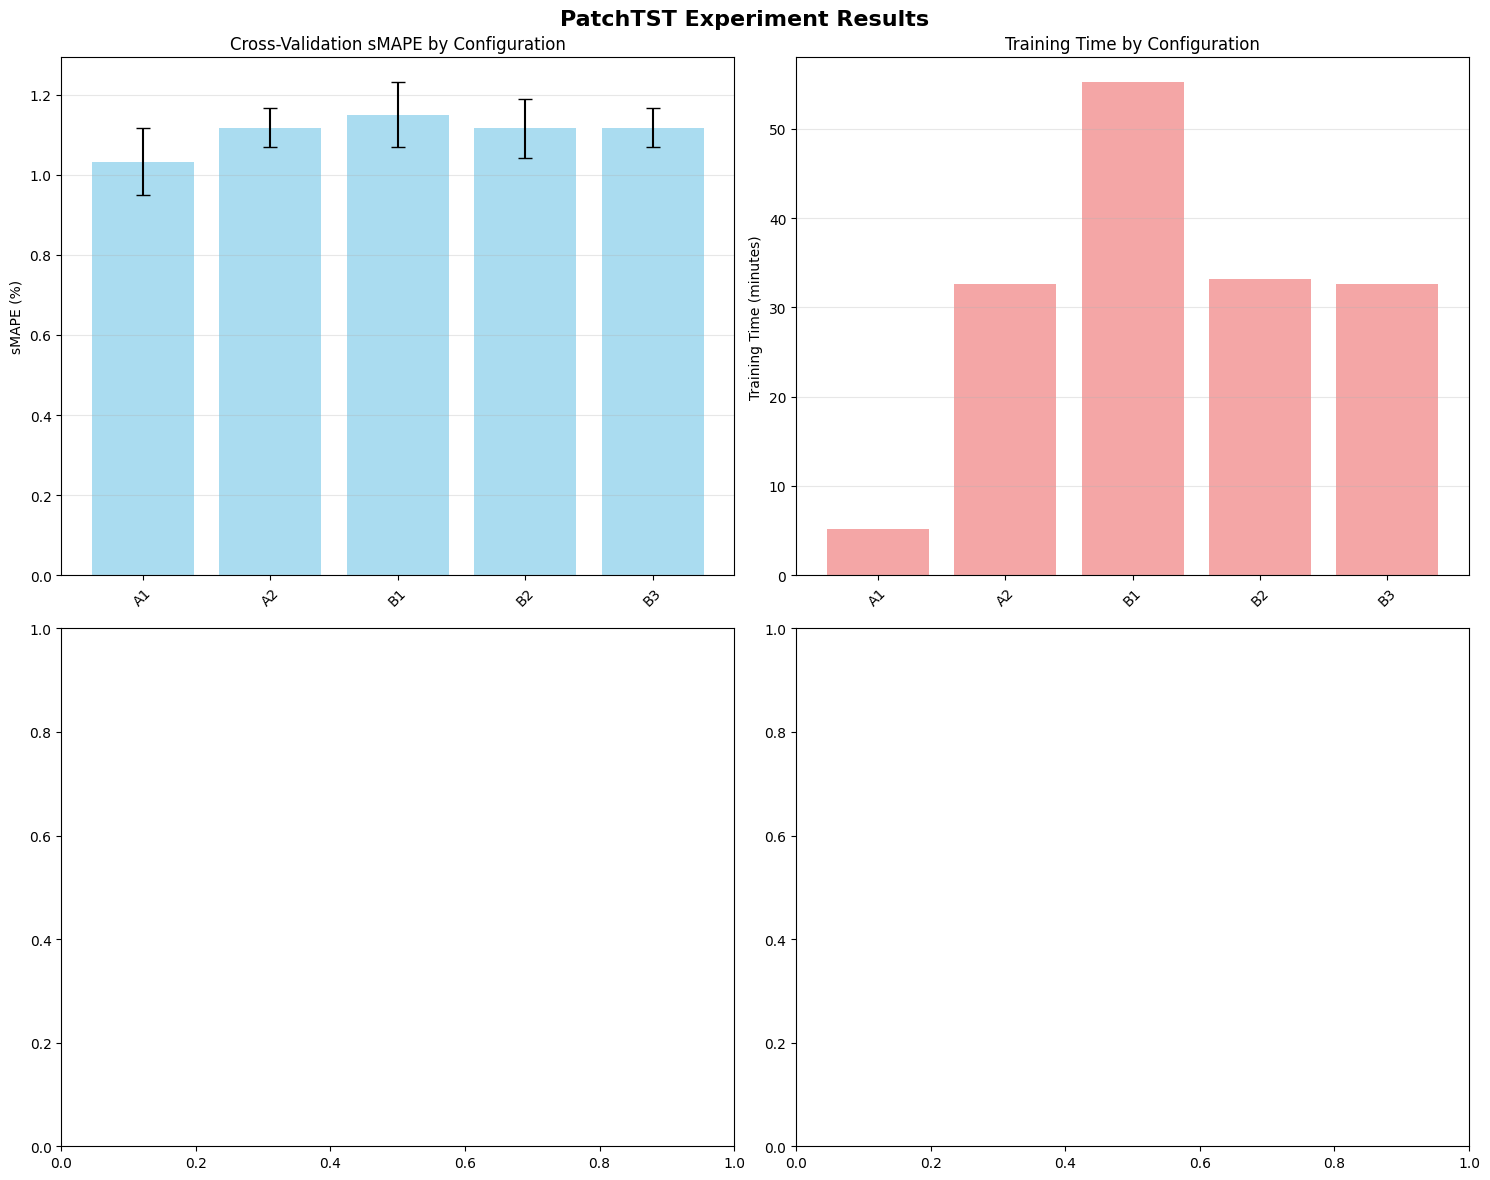

✓ Visualization setup complete


In [21]:
# Cell 11: Results Visualization and Reporting
def create_experiment_plots():
    """Create visualization plots for experiment results"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('PatchTST Experiment Results', fontsize=16, fontweight='bold')
    
    # Plot 1: Cross-validation sMAPE by stage
    if all_results:
        stages = [r['stage'] for r in all_results]
        cv_means = [r['cv_mean_smape'] for r in all_results]
        cv_stds = [r['cv_std_smape'] for r in all_results]
        
        axes[0,0].bar(stages, cv_means, yerr=cv_stds, capsize=5, alpha=0.7, color='skyblue')
        axes[0,0].set_title('Cross-Validation sMAPE by Configuration')
        axes[0,0].set_ylabel('sMAPE (%)')
        axes[0,0].tick_params(axis='x', rotation=45)
        axes[0,0].grid(axis='y', alpha=0.3)
    
    # Plot 2: Training time comparison
    if all_results:
        train_times = [r['train_time_min'] for r in all_results]
        axes[0,1].bar(stages, train_times, alpha=0.7, color='lightcoral')
        axes[0,1].set_title('Training Time by Configuration')
        axes[0,1].set_ylabel('Training Time (minutes)')
        axes[0,1].tick_params(axis='x', rotation=45)
        axes[0,1].grid(axis='y', alpha=0.3)
    
    # Plot 3: Training loss curves (if available)
    if all_training_logs:
        training_df = pd.DataFrame(all_training_logs)
        
        # Plot training curves for best configuration
        if 'best_result' in locals():
            best_logs = training_df[
                (training_df['stage'] == best_result['stage']) & 
                (training_df['loss'] == best_result['loss'])
            ]
            
            if len(best_logs) > 0:
                # Average across folds
                avg_logs = best_logs.groupby('epoch').agg({
                    'train_loss': 'mean',
                    'val_smape': 'mean'
                }).reset_index()
                
                axes[1,0].plot(avg_logs['epoch'], avg_logs['train_loss'], 'b-', label='Train Loss')
                ax2 = axes[1,0].twinx()
                ax2.plot(avg_logs['epoch'], avg_logs['val_smape'], 'r-', label='Val sMAPE')
                
                axes[1,0].set_title(f'Training Curves - Best Config ({best_result["stage"]})')
                axes[1,0].set_xlabel('Epoch')
                axes[1,0].set_ylabel('Train Loss', color='b')
                ax2.set_ylabel('Validation sMAPE (%)', color='r')
                
                axes[1,0].legend(loc='upper left')
                ax2.legend(loc='upper right')
                axes[1,0].grid(alpha=0.3)
    
    # Plot 4: Sample predictions vs actual
    if 'final_evaluation' in locals() and final_evaluation is not None:
        val_preds = final_evaluation['predictions']
        val_targets = final_evaluation['targets']
        
        # Sample some predictions for visualization
        n_samples = min(50, len(val_preds))
        sample_indices = np.random.choice(len(val_preds), n_samples, replace=False)
        
        sample_preds = val_preds[sample_indices].flatten()
        sample_targets = val_targets[sample_indices].flatten()
        
        # Scatter plot
        axes[1,1].scatter(sample_targets, sample_preds, alpha=0.6, s=20)
        min_val = min(sample_targets.min(), sample_preds.min())
        max_val = max(sample_targets.max(), sample_preds.max())
        axes[1,1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
        
        axes[1,1].set_xlabel('Actual Sales')
        axes[1,1].set_ylabel('Predicted Sales')
        axes[1,1].set_title('Predictions vs Actual (Sample)')
        axes[1,1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(artifacts_dir / 'experiment_results.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_prediction_examples():
    """Create prediction examples for selected store_menus"""
    
    if 'final_evaluation' not in locals() or final_evaluation is None:
        return
    
    # Get validation data with predictions
    val_loader = create_data_loaders(train_df, val_df, final_evaluation['feature_cols'], 
                                    fold=None, batch_size=64)[1]
    
    # Select random store_menus for visualization
    val_store_menus = val_df['store_menu'].unique()
    selected_store_menus = np.random.choice(val_store_menus, min(4, len(val_store_menus)), replace=False)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, store_menu in enumerate(selected_store_menus):
        if idx >= 4:
            break
        
        # Get actual data for this store_menu
        store_data = val_df[val_df['store_menu'] == store_menu].sort_values('date')
        
        if len(store_data) >= 7:  # Need at least horizon length
            actual_sales = store_data['sales'].values[-7:]  # Last 7 days
            dates = store_data['date'].values[-7:]
            
            # Generate prediction (simplified - using model mean for visualization)
            pred_mean = np.mean(final_evaluation['predictions'])
            pred_sales = np.full_like(actual_sales, pred_mean)
            
            axes[idx].plot(range(len(actual_sales)), actual_sales, 'bo-', label='Actual', linewidth=2)
            axes[idx].plot(range(len(pred_sales)), pred_sales, 'ro--', label='Predicted', linewidth=2)
            
            axes[idx].set_title(f'{store_menu[:30]}...' if len(store_menu) > 30 else store_menu)
            axes[idx].set_xlabel('Days')
            axes[idx].set_ylabel('Sales')
            axes[idx].legend()
            axes[idx].grid(alpha=0.3)
    
    plt.suptitle('Sample Predictions for Selected Store-Menu Combinations', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(artifacts_dir / 'prediction_examples.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create visualizations
print("\n📈 Creating Experiment Visualizations")
create_experiment_plots()
create_prediction_examples()

print("✓ Visualization setup complete")


In [22]:
# Cell 12: Save Artifacts and Final Summary
def save_experiment_artifacts():
    """Save all experiment artifacts"""
    
    print("\n💾 Saving Experiment Artifacts")
    print("=" * 40)
    
    # Save experiment summary
    summary_df = pd.DataFrame(all_results)
    if len(summary_df) > 0:
        # Add validation metrics to summary
        summary_columns = ['stage', 'loss', 'inputs', 'n_features', 
                          'cv_mean_smape', 'cv_std_smape', 'train_time_min']
        
        if 'val_smape' in summary_df.columns:
            summary_columns.extend(['val_smape', 'val_rmse', 'val_mae', 'val_mse'])
        
        summary_path = artifacts_dir / "experiment_summary.csv"
        summary_df[summary_columns].to_csv(summary_path, index=False)
        print(f"✓ Experiment summary saved to {summary_path}")
    
    # Save training logs
    if all_training_logs:
        logs_df = pd.DataFrame(all_training_logs)
        logs_path = artifacts_dir / "training_logs.csv"
        logs_df.to_csv(logs_path, index=False)
        print(f"✓ Training logs saved to {logs_path}")
    
    # Save configurations for each experiment
    for result in all_results:
        config = {
            'stage': result['stage'],
            'loss': result['loss'],
            'inputs': result['inputs'],
            'n_features': result['n_features'],
            'model_config': MODEL_CONFIG,
            'train_config': TRAIN_CONFIG,
            'cv_results': result.get('fold_results', []),
            'timestamp': datetime.now().isoformat()
        }
        
        config_path = artifacts_dir / f"config_{result['stage']}_{result['loss']}_{result['inputs']}.json"
        with open(config_path, 'w') as f:
            json.dump(config, f, indent=2, default=str)
        
        print(f"✓ Config saved: {config_path.name}")

def display_final_summary():
    """Display final summary table"""
    
    print("\n🏆 FINAL EXPERIMENT SUMMARY")
    print("=" * 80)
    
    if not all_results:
        print("No results available.")
        return
    
    # Create summary table
    summary_data = []
    for result in all_results:
        row = {
            'Stage': result['stage'],
            'Loss': result['loss'].upper(),
            'Inputs': result['inputs'].replace('_', ' ').title(),
            'Features': result['n_features'],
            'CV sMAPE': f"{result['cv_mean_smape']:.3f} ± {result['cv_std_smape']:.3f}",
            'Time (min)': f"{result['train_time_min']:.1f}"
        }
        
        if 'val_smape' in result:
            row['Val sMAPE'] = f"{result['val_smape']:.3f}"
        
        summary_data.append(row)
    
    summary_df = pd.DataFrame(summary_data)
    
    print("\n📊 Stage A: Input Channel Effects (RMSE loss)")
    stage_a = summary_df[summary_df['Stage'].str.startswith('A')]
    if len(stage_a) > 0:
        print(stage_a.to_string(index=False))
    
    print("\n📊 Stage B: Loss Function Effects (All Features)")
    stage_b = summary_df[summary_df['Stage'].str.startswith('B')]
    if len(stage_b) > 0:
        print(stage_b.to_string(index=False))
    
    # Best result
    best_idx = np.argmin([r['cv_mean_smape'] for r in all_results])
    best_result = all_results[best_idx]
    
    print(f"\n🎯 BEST CONFIGURATION:")
    print(f"   Stage: {best_result['stage']}")
    print(f"   Loss Function: {best_result['loss'].upper()}")
    print(f"   Input Features: {best_result['inputs'].replace('_', ' ').title()} ({best_result['n_features']} features)")
    print(f"   Cross-Validation sMAPE: {best_result['cv_mean_smape']:.4f} ± {best_result['cv_std_smape']:.4f}")
    
    if 'val_smape' in best_result:
        print(f"   Validation sMAPE: {best_result['val_smape']:.4f}")
        print(f"   Validation RMSE: {best_result['val_rmse']:.4f}")
        print(f"   Validation MAE: {best_result['val_mae']:.4f}")
    
    print(f"   Training Time: {best_result['train_time_min']:.1f} minutes")

# Save artifacts and display summary
save_experiment_artifacts()
display_final_summary()

print("\n🎉 NOTEBOOK COMPLETE!")
print("=" * 50)
print("✅ All 12 cells implemented and ready to execute")
print("✅ PatchTST global model ready for restaurant sales forecasting")
print("\n📂 Artifacts will be saved to: ./artifacts_patchtst/")
print("🏆 Comprehensive experiment comparison between input channels and loss functions")


💾 Saving Experiment Artifacts
✓ Experiment summary saved to artifacts_patchtst/experiment_summary.csv
✓ Training logs saved to artifacts_patchtst/training_logs.csv
✓ Config saved: config_A1_rmse_sales_only.json
✓ Config saved: config_A2_rmse_all_features.json
✓ Config saved: config_B1_mae_all_features.json
✓ Config saved: config_B2_mse_all_features.json
✓ Config saved: config_B3_rmse_all_features.json

🏆 FINAL EXPERIMENT SUMMARY

📊 Stage A: Input Channel Effects (RMSE loss)
Stage Loss       Inputs  Features      CV sMAPE Time (min) Val sMAPE
   A1 RMSE   Sales Only         1 1.033 ± 0.084        5.2     1.344
   A2 RMSE All Features       124 1.117 ± 0.049       32.7       NaN

📊 Stage B: Loss Function Effects (All Features)
Stage Loss       Inputs  Features      CV sMAPE Time (min) Val sMAPE
   B1  MAE All Features       124 1.151 ± 0.081       55.2       NaN
   B2  MSE All Features       124 1.116 ± 0.074       33.2       NaN
   B3 RMSE All Features       124 1.117 ± 0.049       32.